## 1. Project Introduction

Customer Purchase Behavior Analysis

Objective:
Analyze purchasing behavior of different customer segments and identify high-value customers.

## 2. Import Libraries

## 3. Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
transactions = pd.read_excel("QVI_transaction_data.xlsx")
customers = pd.read_csv("QVI_purchase_behaviour.csv")

## 4. Understanding of Data

In [3]:
transactions.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [4]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


In [5]:
transactions.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836.000000,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,43464.036260,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
std,105.389282,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226
min,43282.000000,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,43373.000000,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,43464.000000,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,43555.000000,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,43646.000000,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000


In [6]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [7]:
customers.describe()

,LYLTY_CARD_NBR
count,7.263700e+04
mean,1.361859e+05
std,8.989293e+04
min,1.000000e+03
25%,6.620200e+04
50%,1.340400e+05
75%,2.033750e+05
max,2.373711e+06


In [8]:
transactions.isnull().sum()

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

In [9]:
customers.isnull().sum()

LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

## 5. Data Cleaning

Convert Date into proper format

In [10]:
transactions["DATE"] = pd.to_datetime(transactions["DATE"], origin='1899-12-30', unit="D")

In [11]:
transactions["DATE"].head()

0   2018-10-17
1   2019-05-14
2   2019-05-20
3   2018-08-17
4   2018-08-18
Name: DATE, dtype: datetime64[ns]

In [12]:
transactions["PROD_NAME"].head()

0      Natural Chip        Compny SeaSalt175g
1                    CCs Nacho Cheese    175g
2      Smiths Crinkle Cut  Chips Chicken 170g
3      Smiths Chip Thinly  S/Cream&Onion 175g
4    Kettle Tortilla ChpsHny&Jlpno Chili 150g
Name: PROD_NAME, dtype: object

In [13]:
type(transactions)

pandas.core.frame.DataFrame

In [14]:
# Remove Salsa Products
transactions = transactions[~transactions["PROD_NAME"].str.contains('salsa', case=False)]
transactions.reset_index(drop=True, inplace=True)

In [15]:
transactions.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [16]:
type(transactions)

pandas.core.frame.DataFrame

In [17]:
transactions["PACK_SIZE"] = transactions["PROD_NAME"].str.extract("(\d+)").astype(int)

In [18]:
transactions.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150


In [19]:
transactions["PROD_QTY"].describe()

count    246742.000000
mean          1.908062
std           0.659831
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max         200.000000
Name: PROD_QTY, dtype: float64

In [20]:
transactions["TOT_SALES"].describe()

count    246742.000000
mean          7.321322
std           3.077828
min           1.700000
25%           5.800000
50%           7.400000
75%           8.800000
max         650.000000
Name: TOT_SALES, dtype: float64

In [21]:
transactions[transactions["PROD_QTY"] == 200]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE
64955,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0,380
64956,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0,380


In [22]:
transactions[transactions["TOT_SALES"] == 650]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE
64955,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0,380
64956,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0,380


In [23]:
transactions = transactions[transactions["PROD_QTY"] != 200]

In [24]:
transactions["PROD_QTY"].describe()
transactions["TOT_SALES"].describe()

count    246740.000000
mean          7.316113
std           2.474897
min           1.700000
25%           5.800000
50%           7.400000
75%           8.800000
max          29.500000
Name: TOT_SALES, dtype: float64

Two extream outlier transactions were identified where a single customer purchased 200 units in one transaction. As this behaviour does not reflected typical household purchasing pattern, this transactions were removed to accurate customer behaviour analysis

In [25]:
transactions["PROD_QTY"].describe()

count    246740.000000
mean          1.906456
std           0.342499
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max           5.000000
Name: PROD_QTY, dtype: float64

## 6. Feature Engineering

In [26]:
transactions["PROD_NAME"].value_counts().head(5)

PROD_NAME
Kettle Mozzarella   Basil & Pesto 175g      3304
Kettle Tortilla ChpsHny&Jlpno Chili 150g    3296
Cobs Popd Swt/Chlli &Sr/Cream Chips 110g    3269
Tyrrells Crisps     Ched & Chives 165g      3268
Cobs Popd Sea Salt  Chips 110g              3265
Name: count, dtype: int64

In [27]:
# Create Brand Properly
transactions["BRAND"] = transactions["PROD_NAME"].str.split().str[0]

In [28]:
transactions[["PROD_NAME", "BRAND"]].head()

,PROD_NAME,BRAND
0,Natural Chip Compny SeaSalt175g,Natural
1,CCs Nacho Cheese 175g,CCs
2,Smiths Crinkle Cut Chips Chicken 170g,Smiths
3,Smiths Chip Thinly S/Cream&Onion 175g,Smiths
4,Kettle Tortilla ChpsHny&Jlpno Chili 150g,Kettle


## 7. Merge Dataset

In [29]:
data = transactions.merge(customers, on="LYLTY_CARD_NBR", how="left")

In [30]:
data.shape

(246740, 12)

In [31]:
data.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,Natural,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175,CCs,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170,Smiths,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175,Smiths,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150,Kettle,MIDAGE SINGLES/COUPLES,Budget


# 8. Exploratory Data Analysis (EDA)

## Sales by LIFESTAGE

In [32]:
sales_by_lifestage = data.groupby("LIFESTAGE")["TOT_SALES"].sum().sort_values(ascending=False)
sales_by_lifestage

LIFESTAGE
OLDER SINGLES/COUPLES     376019.65
RETIREES                  342381.90
OLDER FAMILIES            328519.90
YOUNG FAMILIES            294627.90
YOUNG SINGLES/COUPLES     243756.60
MIDAGE SINGLES/COUPLES    172523.80
NEW FAMILIES               47347.95
Name: TOT_SALES, dtype: float64

In [33]:
# Count Customers Per LIFESTAGE
data.groupby("LIFESTAGE")["LYLTY_CARD_NBR"].nunique().sort_values(ascending=False)

LIFESTAGE
RETIREES                  14555
OLDER SINGLES/COUPLES     14389
YOUNG SINGLES/COUPLES     14044
OLDER FAMILIES             9630
YOUNG FAMILIES             9036
MIDAGE SINGLES/COUPLES     7141
NEW FAMILIES               2492
Name: LYLTY_CARD_NBR, dtype: int64

RETIREES = Highest Customer Per Count

In [34]:
# Calculate Average spend per customer
(data.groupby("LIFESTAGE")["TOT_SALES"].sum() /
 data.groupby("LIFESTAGE")["LYLTY_CARD_NBR"].nunique()).sort_values(ascending=False)

LIFESTAGE
OLDER FAMILIES            34.114216
YOUNG FAMILIES            32.606009
OLDER SINGLES/COUPLES     26.132438
MIDAGE SINGLES/COUPLES    24.159613
RETIREES                  23.523318
NEW FAMILIES              18.999980
YOUNG SINGLES/COUPLES     17.356636
dtype: float64

In [35]:
# Unit purchase per customer
(data.groupby("LIFESTAGE")["PROD_QTY"].sum() /
data.groupby("LIFESTAGE")["LYLTY_CARD_NBR"].nunique()).sort_values(ascending=False)

LIFESTAGE
OLDER FAMILIES            9.127310
YOUNG FAMILIES            8.695994
OLDER SINGLES/COUPLES     6.754118
MIDAGE SINGLES/COUPLES    6.231060
RETIREES                  6.037444
NEW FAMILIES              4.843499
YOUNG SINGLES/COUPLES     4.436058
dtype: float64

OLDER FAMILIES = Highest Unit Per Customer

In [36]:
# Averagre Price Per Unit
(data.groupby("LIFESTAGE")["TOT_SALES"].sum() /
data.groupby("LIFESTAGE")["PROD_QTY"].sum()).sort_values(ascending=False)

LIFESTAGE
NEW FAMILIES              3.922780
YOUNG SINGLES/COUPLES     3.912626
RETIREES                  3.896238
MIDAGE SINGLES/COUPLES    3.877288
OLDER SINGLES/COUPLES     3.869112
YOUNG FAMILIES            3.749544
OLDER FAMILIES            3.737598
dtype: float64

NEW FAMILIES = Highest Price Per Unit

## Purchase Frequency

In [37]:
# Transaction Per Customer
txn_per_customer = data.groupby("LYLTY_CARD_NBR")["TXN_ID"].nunique().reset_index()
txn_per_customer.columns = ["Customer", "Transaction_Count"]
txn_per_customer["Transaction_Count"].describe()

count    71287.000000
mean         3.440417
std          2.434758
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max         17.000000
Name: Transaction_Count, dtype: float64

customer

🧠 Understanding Each Line
🔹 count = 72,636

You have 72,636 unique customers

Good. Matches your customer dataset.

🔹 mean = 3.62

On average:

👉 Each customer shops ~3.6 times

That means customers are not one-time only buyers.

🔹 min = 1

Some customers bought only once.

These are one-time buyers.

🔹 25% = 1

25% of customers purchased only once.

That means:

One-fourth of your customers are not repeat buyers.

Important insight.

🔹 50% (median) = 3

Half of customers purchased 3 times or less.

So typical customer buys around 3 times.

🔹 75% = 5

75% of customers purchased 5 times or less.

So only top 25% buy more than 5 times.

🔹 max = 18

Your most loyal customer purchased 18 times.

That’s a strong repeat buyer.

In [38]:
# Exact Repeat Buyer Counts
(txn_per_customer["Transaction_Count"] > 1).sum()

51717

In [39]:
# One-time buyer
(txn_per_customer["Transaction_Count"] == 1).sum()

19570

## Revenue per transcation

In [40]:
rev_per_txn = data.groupby("TXN_ID")["TOT_SALES"].sum().reset_index()
rev_per_txn["TOT_SALES"].describe()

count    245255.000000
mean          7.360411
std           2.549377
min           1.700000
25%           5.800000
50%           7.400000
75%           8.800000
max          33.000000
Name: TOT_SALES, dtype: float64

## Revenue per transaction by LIFESTAGE

In [41]:
rev_lifestage = data.groupby(["LIFESTAGE", "TXN_ID"])["TOT_SALES"].sum().reset_index()
basket_value = rev_lifestage.groupby("LIFESTAGE")["TOT_SALES"].mean().reset_index()
basket_value.sort_values("TOT_SALES", ascending=False)

,LIFESTAGE,TOT_SALES
3,OLDER SINGLES/COUPLES,7.445049
0,MIDAGE SINGLES/COUPLES,7.417507
4,RETIREES,7.410062
2,OLDER FAMILIES,7.340407
5,YOUNG FAMILIES,7.330876
1,NEW FAMILIES,7.310167
6,YOUNG SINGLES/COUPLES,7.198317


Basket_Value = Same Across All Segments

What This Means Stategically

if julia want to increase revenue:
increase basket size may be hard

🚀 Best Strategies
1. Increase Visit Frequency
2. Increase No.of Customers
3. Promote Repeat Buying

Now We Check:
Which Segment Contributes Most To Total Segments ?

In [42]:
segment_revenue = data.groupby("LIFESTAGE")["TOT_SALES"].sum()
(segment_revenue / segment_revenue.sum() * 100).sort_values(ascending=False)

LIFESTAGE
OLDER SINGLES/COUPLES     20.830063
RETIREES                  18.966659
OLDER FAMILIES            18.198757
YOUNG FAMILIES            16.321269
YOUNG SINGLES/COUPLES     13.503191
MIDAGE SINGLES/COUPLES     9.557164
NEW FAMILIES               2.622897
Name: TOT_SALES, dtype: float64

In [43]:
# Check If They Overr-Indexed Compared to their Population
customer_share = data.groupby("LIFESTAGE")["LYLTY_CARD_NBR"].nunique()
(customer_share / customer_share.sum() * 100).sort_values(ascending=False)

LIFESTAGE
RETIREES                  20.417467
OLDER SINGLES/COUPLES     20.184606
YOUNG SINGLES/COUPLES     19.700647
OLDER FAMILIES            13.508774
YOUNG FAMILIES            12.675523
MIDAGE SINGLES/COUPLES    10.017254
NEW FAMILIES               3.495729
Name: LYLTY_CARD_NBR, dtype: float64

🧠 How To Interpret This:

Revenue % - Customer %

If Revenue% > Customer% = It Means Segments Spends More Than Average

If Customer% < Revenue% = Segments Spends Less Than Average 

🔥 Strongest Segments

🥇 Older Families

13.46% Customers
18.23% Revenue

They are much more valuable per person

🥈 Young Families

12.63% Customers
16.35% Revenue

Also strong spenders

🥉 Older Singles/Couples

20.11% Customers
20.28% Revenue

Balaced but slightly overperforming group

Very stabel high-value group

🎯 Big Stategic Insights

Top Values Segments are:
1. Older Families
2. Younger Families
3. Older Singles/Couples

Improvement Opportunity

Younger Singles/Couples

## Analyze Pack Size Preference by Customer Segment

In [44]:
# Extract Packet Size
data["PACK_SIZE"] = data["PROD_NAME"].str.extract("(\d+)").astype(int)

In [45]:
# Pack Size by LIFESTAGE
pack_lifestage = data.groupby(["LIFESTAGE", "PACK_SIZE"])["TOT_SALES"].sum().reset_index()

In [46]:
# Find Most Popular Pack Size Per Segement
pack_lifestage.sort_values(["LIFESTAGE", "TOT_SALES"], ascending=[True,False]).groupby("LIFESTAGE").head(3)

,LIFESTAGE,PACK_SIZE,TOT_SALES
10,MIDAGE SINGLES/COUPLES,175,46765.2
6,MIDAGE SINGLES/COUPLES,150,27422.2
4,MIDAGE SINGLES/COUPLES,134,16875.7
30,NEW FAMILIES,175,12754.3
26,NEW FAMILIES,150,7485.0
24,NEW FAMILIES,134,4898.8
50,OLDER FAMILIES,175,88563.5
46,OLDER FAMILIES,150,53119.2
44,OLDER FAMILIES,134,30584.2
70,OLDER SINGLES/COUPLES,175,100931.9


## Brand Preference by Segment

In [47]:
# Revenue by Brand & Lifestage
brand_segment = data.groupby(["LIFESTAGE"])["TOT_SALES"].sum().reset_index()

In [48]:
# Top brand by per segment
brand_segment.sort_values(["LIFESTAGE", "TOT_SALES"], ascending=[True,False]).groupby("LIFESTAGE").head(3)

,LIFESTAGE,TOT_SALES
0,MIDAGE SINGLES/COUPLES,172523.80
1,NEW FAMILIES,47347.95
2,OLDER FAMILIES,328519.90
3,OLDER SINGLES/COUPLES,376019.65
4,RETIREES,342381.90
5,YOUNG FAMILIES,294627.90
6,YOUNG SINGLES/COUPLES,243756.60


# 9. Customer Behavior Analysis

This section analyzes how different customer segment behaves in terms of:

- Shopping frequency
- Revenue per transaction
- Total sales contribution

### 9.1 Customer count by Lifestage

In [49]:
customer_count = data.groupby("LIFESTAGE")["LYLTY_CARD_NBR"].nunique().sort_values(ascending=False)
customer_count

LIFESTAGE
RETIREES                  14555
OLDER SINGLES/COUPLES     14389
YOUNG SINGLES/COUPLES     14044
OLDER FAMILIES             9630
YOUNG FAMILIES             9036
MIDAGE SINGLES/COUPLES     7141
NEW FAMILIES               2492
Name: LYLTY_CARD_NBR, dtype: int64

Explanation:

• Counts unique customers in each segment.

• Helps identify largest customer groups.

### 9.2 Total Sales by Lifestage

In [50]:
sales_lifestage = data.groupby("LIFESTAGE")["TOT_SALES"].sum().sort_values(ascending=False)
sales_lifestage

LIFESTAGE
OLDER SINGLES/COUPLES     376019.65
RETIREES                  342381.90
OLDER FAMILIES            328519.90
YOUNG FAMILIES            294627.90
YOUNG SINGLES/COUPLES     243756.60
MIDAGE SINGLES/COUPLES    172523.80
NEW FAMILIES               47347.95
Name: TOT_SALES, dtype: float64

####  Visualisation

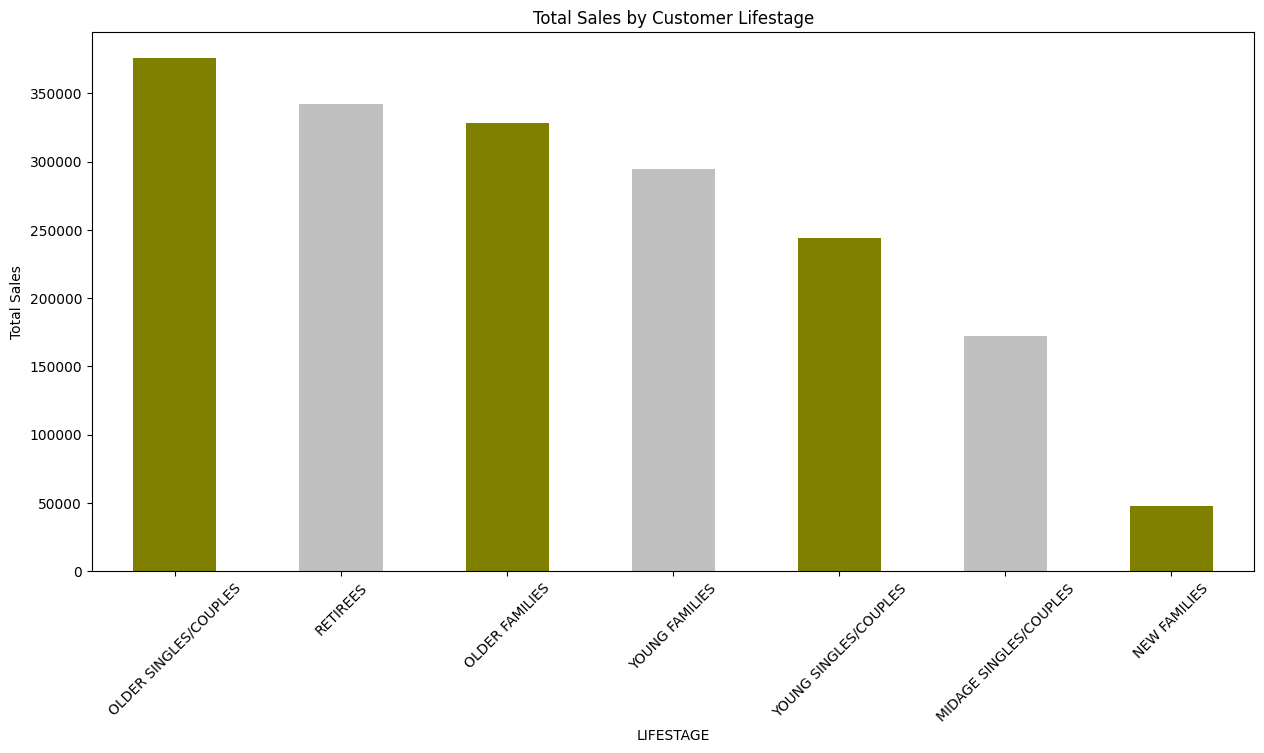

In [51]:
sales_lifestage.plot(kind="bar", figsize=(15,7), color=("olive", "silver"))
plt.title("Total Sales by Customer Lifestage")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.savefig("visuals/Total_Sales_by_Customer_Lifestage.png",  bbox_inches="tight")
plt.show()


Older Singles/Couples contributes the highest revenue amongs all segments

## 9.3 Revenue per Transaction

In [52]:
revenue_per_transaction = data.groupby("LIFESTAGE")["TOT_SALES"].mean().sort_values(ascending=False)
revenue_per_transaction

LIFESTAGE
OLDER SINGLES/COUPLES     7.402982
RETIREES                  7.373994
MIDAGE SINGLES/COUPLES    7.373442
NEW FAMILIES              7.287664
YOUNG FAMILIES            7.275841
OLDER FAMILIES            7.274899
YOUNG SINGLES/COUPLES     7.175854
Name: TOT_SALES, dtype: float64

### Visualisation

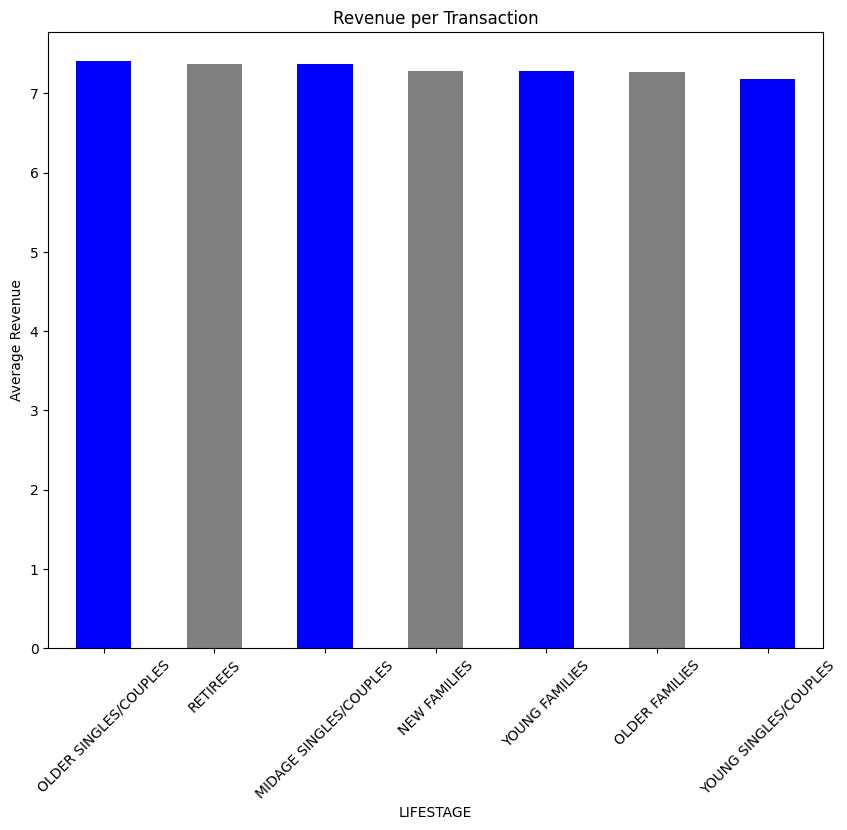

In [53]:
revenue_per_transaction.plot(kind="bar", figsize=(10,8), color=("Blue", "Grey"))
plt.title("Revenue per Transaction")
plt.ylabel("Average Revenue")
plt.xticks(rotation=45)
plt.savefig("visuals/Revenue_Per_Transaction.png", bbox_inches="tight")
plt.show()

Older Singles/Couples spend more per transaction compared to other customer segments

## 9.4 Shopping Frequency (Repeat Buyers)

In [54]:
transaction_count = data.groupby("LYLTY_CARD_NBR")["TXN_ID"].nunique()
transaction_count.describe()

count    71287.000000
mean         3.440417
std          2.434758
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max         17.000000
Name: TXN_ID, dtype: float64

Most customers shop between 1-5 times, indicating moderate repeat purchasing behaviour

## 10 Brand Preference by customer segment

Brand Preference Analysis

This analysis identifies which chip brands are most popular among different customer segments

### 10.1 Brand Extraction

In [55]:
data["BRAND"] = data["PROD_NAME"].str.split().str[0]

### 10.2 Brand Sales

In [56]:
brand_sales = data.groupby("BRAND")["TOT_SALES"].sum().sort_values(ascending=False)
brand_sales.head(10)

BRAND
Kettle       390239.8
Smiths       202908.6
Doritos      187277.9
Pringles     177655.5
Thins         88852.5
Twisties      81522.1
Tostitos      79789.6
Infuzions     76247.6
Cobs          70569.8
RRD           64954.5
Name: TOT_SALES, dtype: float64

### 10.3 Brand Preferece by Lifestage

In [57]:
brand_segment = data.groupby(["LIFESTAGE", "BRAND"])["TOT_SALES"].sum().reset_index()

In [58]:
# Top Brands per segment
top_brands = brand_segment.sort_values(["LIFESTAGE", "TOT_SALES"], ascending=[True, False])
top_brands.head(10)

,LIFESTAGE,BRAND,TOT_SALES
12,MIDAGE SINGLES/COUPLES,Kettle,38358.2
19,MIDAGE SINGLES/COUPLES,Smiths,19011.5
6,MIDAGE SINGLES/COUPLES,Doritos,17922.1
15,MIDAGE SINGLES/COUPLES,Pringles,16875.7
22,MIDAGE SINGLES/COUPLES,Thins,8269.8
24,MIDAGE SINGLES/COUPLES,Twisties,8004.2
23,MIDAGE SINGLES/COUPLES,Tostitos,7779.2
10,MIDAGE SINGLES/COUPLES,Infuzions,7340.6
4,MIDAGE SINGLES/COUPLES,Cobs,6995.8
16,MIDAGE SINGLES/COUPLES,RRD,5792.1


### Visualisation

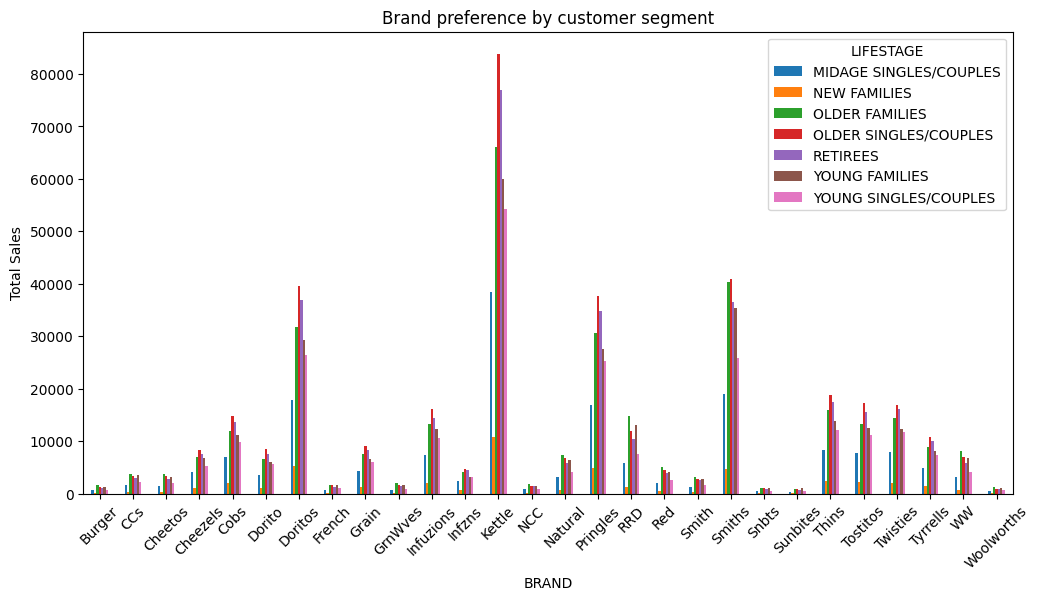

In [59]:
pivot_brand = brand_segment.pivot(index="BRAND", columns="LIFESTAGE", values="TOT_SALES")

os.makedirs("visuals", exist_ok=True)
pivot_brand.plot(kind="bar", figsize=(12, 6))
plt.title("Brand preference by customer segment")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.savefig("visuals/sales_by_lifestage.png", bbox_inches="tight")
plt.show()

In [60]:
# Saved Clean Dataset
data.to_csv("Cleaned_data.csv", index=False)

## Key Insights

• Older Singles/Couples contribute the highest revenue per transaction.

• Retirees and Older Families represent a large portion of total sales.

• Most customers shop between 1–5 times, indicating moderate repeat buying behaviour.

• Certain brands dominate sales across multiple customer segments.

## 📊 Final Insights

### 1. Older/Singles Couples Drive the Highest Revenue

Older Singles/Couples contribute the largest share of total sales among all customer segments.

This indicates they are a high-value customer group for the chips category

### 2. Retires also Represent a Large Customer Base

Retires account for a significant portion of customers and transactions, making them an important segment for sustained revenue

### 3. Families purchase Higher Quantities

Young Families and Older Families tend to purchase more units per transaction, suggesting household consumption and shared snacking behavior

### 4. 175g Packs Dominate the Market

Across all segments, 175g packs generate the highes sales, followed by 150g and 134g packs.

Customers appear to prefer mid-to-large pack sizes that offer better value

### 5. Revenue Per Transaction is Consistent Across Segments

The average transaction value is around $7, with only small variations between customer segments.

This suggests customers generally spend similar amount per purchase.

### 6. Brand Prefernce Varies Across Segments

Different customer groups show varying brand preferneces, which indicates opportunities for tageted marketing campaingns

## 🎯Business Recommendations

### Recommendation 1

Focus marketing effors on Older Singles/Couples, as they generate the highest revenue

### Recommendation 2

Promte 175g pack sizes more aggressively since they dominate sales across segments.

### Recommendation 3

Introduce family bundle promotions for Young Families and Older Families

### Recommendation 4

Optimize Shelf Placement for top-performing brands to increase visiblity and sales

## 🏁 Conclusion

The analysis highlights clear purchasing patterns across customer life stages.
Older Singer/Couples and Retirees contribute significantly to overall sales, while families drive higher product quantities.

Understanding these behaviors can help retailers optimize product assortment, promotions, and marketing strategies to maximize category performance